### Загрузка данных
Загружаем первые 10 млн строк за ноябрь 2019 (датасет e-commerce поведения пользователей).
Данные содержат события: просмотры, добавления в корзину, покупки.

In [1]:
import pandas as pd

df=pd.read_csv('/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv', nrows=10000000)

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [2]:
print(f'размер: {df.shape}')
print(f'пропусков:\n{df.isnull().sum()}')
print(f'\nраспределение типов событий:\n{df['event_type'].value_counts()}')

размер: (10000000, 9)
пропусков:
event_time             0
event_type             0
product_id             0
category_id            0
category_code    3302790
brand            1410463
price                  0
user_id                0
user_session           0
dtype: int64

распределение типов событий:
event_type
view        9731128
purchase     147105
cart         121767
Name: count, dtype: int64


In [3]:
df['category_code']=df['category_code'].fillna('unknown')
df['brand']=df['brand'].fillna('unknown')

print(f'пропусков: {df.isnull().sum().sum().item()}')

пропусков: 0


### Создание пользовательских признаков
Агрегируем события по `user_id`:
- счётчики событий (просмотры, корзины, покупки)
- средний чек и сумма трат
- уникальные категории и бренды
- первое и последнее событие (для расчёта активности)

In [4]:
# счётчики событий
total_views = df[df['event_type']=='view'].groupby('user_id').size().rename('total_views')
total_purchases = df[df['event_type']=='purchase'].groupby('user_id').size().rename('total_purchases')
total_carts = df[df['event_type']=='cart'].groupby('user_id').size().rename('total_carts')

purchases = df[df['event_type']=='purchase'].groupby('user_id')['price'].agg(['mean', 'sum'])
purchases = purchases.rename(columns={'mean': 'avg_price_purchased', 'sum': 'total_spent'})

# уникальные категории и бренды
unique_cat = df.groupby('user_id')['category_code'].nunique().rename('unique_categories')
unique_brand = df.groupby('user_id')['brand'].nunique().rename('unique_brands')

first_last = df.groupby('user_id')['event_time'].agg(['min', 'max'])
first_last = first_last.rename(columns={'min': 'first_event', 'max': 'last_event'})

# собираем всё
user_features = pd.concat([
    total_views, total_purchases, total_carts,
    purchases, unique_cat, unique_brand, first_last
], axis=1).fillna(0).reset_index()

user_features['first_event'] = pd.to_datetime(user_features['first_event'])
user_features['last_event'] = pd.to_datetime(user_features['last_event'])

print(f"пользователей: {len(user_features)}")
user_features.head()

пользователей: 1104582


,user_id,total_views,total_purchases,total_carts,avg_price_purchased,total_spent,unique_categories,unique_brands,first_event,last_event
0,10300217,1.0,0.0,0.0,0.0,0.0,1,1,2019-11-06 06:51:52+00:00,2019-11-06 06:51:52+00:00
1,161080209,1.0,0.0,0.0,0.0,0.0,1,1,2019-11-04 16:41:56+00:00,2019-11-04 16:41:56+00:00
2,170180460,1.0,0.0,0.0,0.0,0.0,1,1,2019-11-04 14:10:47+00:00,2019-11-04 14:10:47+00:00
3,208701646,3.0,0.0,0.0,0.0,0.0,1,1,2019-11-06 10:27:47+00:00,2019-11-06 10:32:30+00:00
4,214470341,2.0,0.0,0.0,0.0,0.0,1,1,2019-11-04 02:59:33+00:00,2019-11-04 02:59:33+00:00


### Производные признаки
- `conversion_rate` = покупки / просмотры
- `active_days` = (последний день - первый день) + 1

In [5]:
# конверсия (покупки/просмотры)
user_features['conversion_rate'] = user_features['total_purchases'] / (user_features['total_views'] + 1e-6)

# активные дни
user_features['active_days'] = (user_features['last_event'] - user_features['first_event']).dt.days + 1

user_features.head()

,user_id,total_views,total_purchases,total_carts,avg_price_purchased,total_spent,unique_categories,unique_brands,first_event,last_event,conversion_rate,active_days
0,10300217,1.0,0.0,0.0,0.0,0.0,1,1,2019-11-06 06:51:52+00:00,2019-11-06 06:51:52+00:00,0.0,1
1,161080209,1.0,0.0,0.0,0.0,0.0,1,1,2019-11-04 16:41:56+00:00,2019-11-04 16:41:56+00:00,0.0,1
2,170180460,1.0,0.0,0.0,0.0,0.0,1,1,2019-11-04 14:10:47+00:00,2019-11-04 14:10:47+00:00,0.0,1
3,208701646,3.0,0.0,0.0,0.0,0.0,1,1,2019-11-06 10:27:47+00:00,2019-11-06 10:32:30+00:00,0.0,1
4,214470341,2.0,0.0,0.0,0.0,0.0,1,1,2019-11-04 02:59:33+00:00,2019-11-04 02:59:33+00:00,0.0,1


### Фильтрация неактивных пользователей
Оставляем только тех, у кого суммарно >=5 событий.
Это убирает «шум» - пользователей, которые зашли 1-2 раза и ушли.

In [6]:
# удаляем неактивных пользователей

user_features=user_features[(user_features['total_views']+user_features['total_purchases']+user_features['total_carts'])>=5]

print(f'осталось пользователей: {len(user_features)}\n')
user_features.head()

осталось пользователей: 500646



,user_id,total_views,total_purchases,total_carts,avg_price_purchased,total_spent,unique_categories,unique_brands,first_event,last_event,conversion_rate,active_days
7,226242984,5.0,0.0,3.0,0.0,0.0,1,1,2019-11-04 11:59:06+00:00,2019-11-04 12:32:55+00:00,0.0,1
16,260013793,17.0,0.0,0.0,0.0,0.0,2,5,2019-11-03 06:10:15+00:00,2019-11-03 06:17:03+00:00,0.0,1
17,265601964,6.0,0.0,0.0,0.0,0.0,3,4,2019-11-03 17:28:01+00:00,2019-11-04 11:45:39+00:00,0.0,1
20,272811580,17.0,0.0,0.0,0.0,0.0,1,3,2019-11-05 09:16:41+00:00,2019-11-05 19:40:21+00:00,0.0,1
25,276618064,8.0,0.0,0.0,0.0,0.0,2,2,2019-11-03 01:05:51+00:00,2019-11-03 01:10:33+00:00,0.0,1


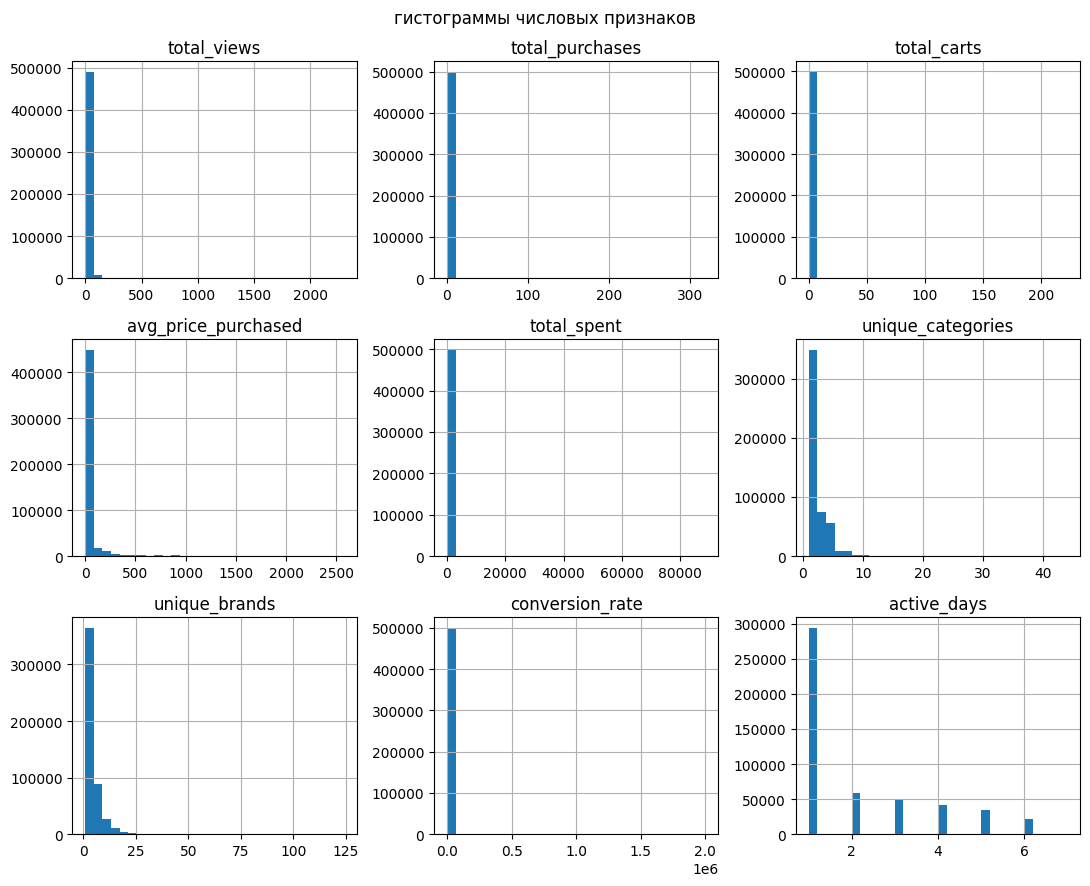

In [7]:
import matplotlib.pyplot as plt
import seaborn

num_cols=['total_views','total_purchases','total_carts','avg_price_purchased','total_spent',
         'unique_categories', 'unique_brands','conversion_rate','active_days']

user_features[num_cols].hist(bins=30, figsize=(11,9))
plt.suptitle('гистограммы числовых признаков')
plt.tight_layout()

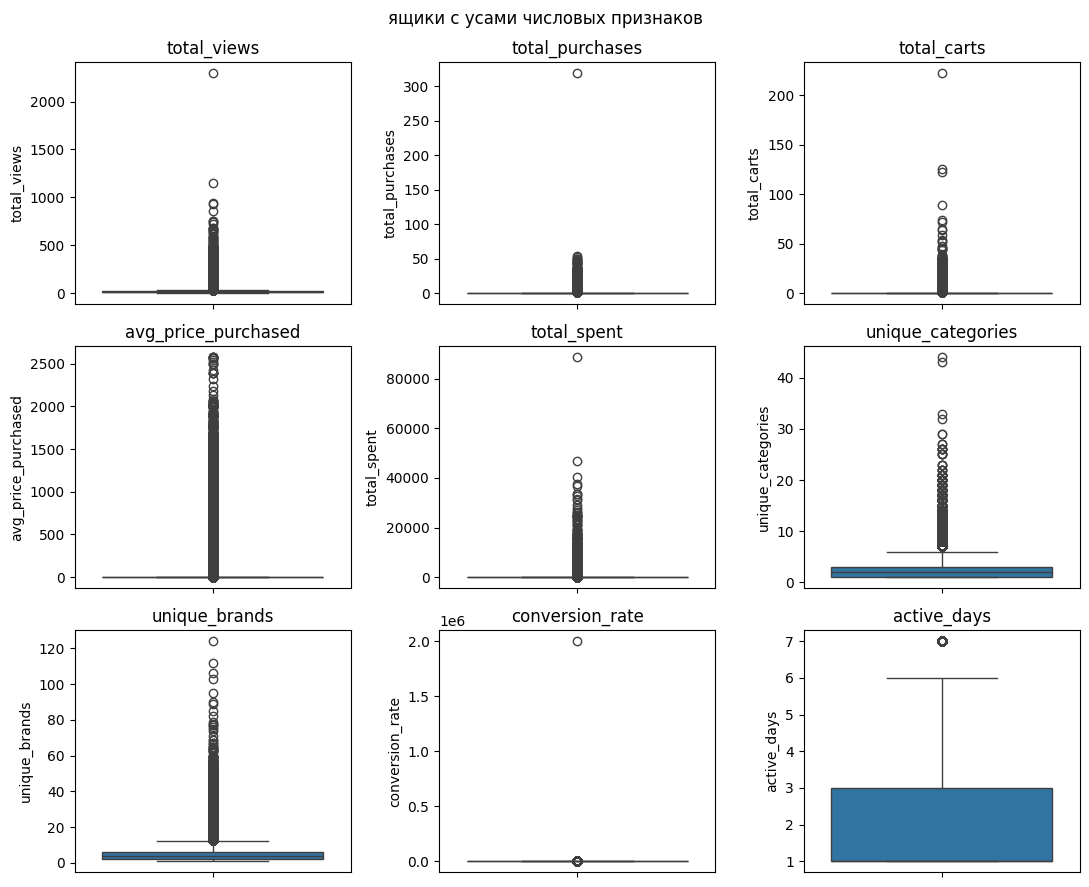

In [8]:
import seaborn as sns

plt.figure(figsize=(11, 9))

for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(data=user_features, y=col)
    plt.title(col)

plt.suptitle('ящики с усами числовых признаков')
plt.tight_layout()

In [9]:
from sklearn.preprocessing import StandardScaler

df_final=user_features.copy()

scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_final[num_cols])

print(f'X_scaled: {X_scaled.shape}')

X_scaled: (500646, 9)


### Выбор числа кластеров: метод локтя
Ищем точку, где инерция перестаёт резко падать.

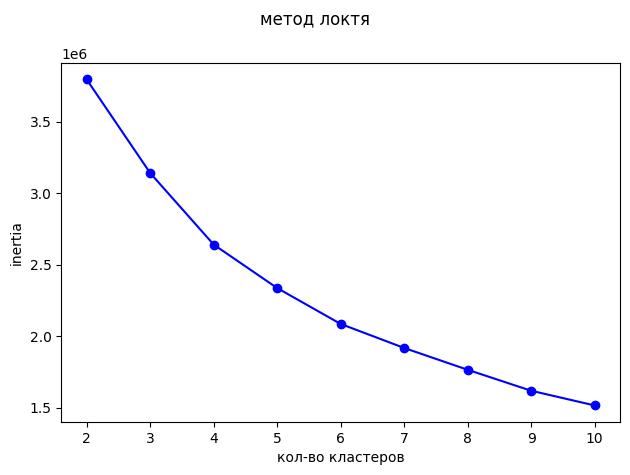

In [10]:
from sklearn.cluster import KMeans

inertia=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,11), inertia, 'b-o')
plt.xlabel('кол-во кластеров')
plt.ylabel('inertia')
plt.suptitle('метод локтя')

plt.tight_layout()

### Выбор числа кластеров: силуэт
Метрика качества кластеризации. Чем выше, тем лучше.
Считаем на выборке 50k (для скорости).

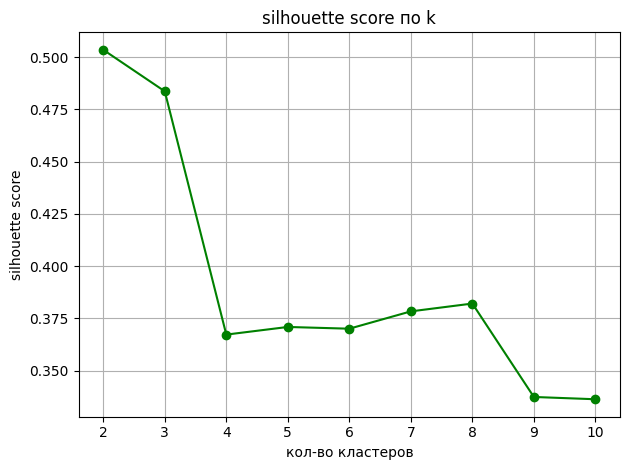

In [16]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np

np.random.seed(42)
X_sample=X_scaled[np.random.choice(len(X_scaled), 100000, replace=False)]

silhouette_scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
    labels=kmeans.fit_predict(X_sample)
    score=silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

plt.plot(range(2,11), silhouette_scores, 'g-o')
plt.xlabel('кол-во кластеров')
plt.ylabel('silhouette score')
plt.title('silhouette score по k')
plt.grid()

plt.tight_layout()

### График силуэта

- **VIP-кластер (1)** сформирован хорошо (все точки в плюсе).
- **Кластеры 0 и 2** частично уходят в минус - значит, их точки местами ближе к соседним кластерам.

В данных 81% пользователей - «пассивные зрители» (почти без покупок). Они очень похожи друг на друга и образуют плотное ядро. На их фоне маленькие кластеры VIP и активных пользователей выглядят размыто.

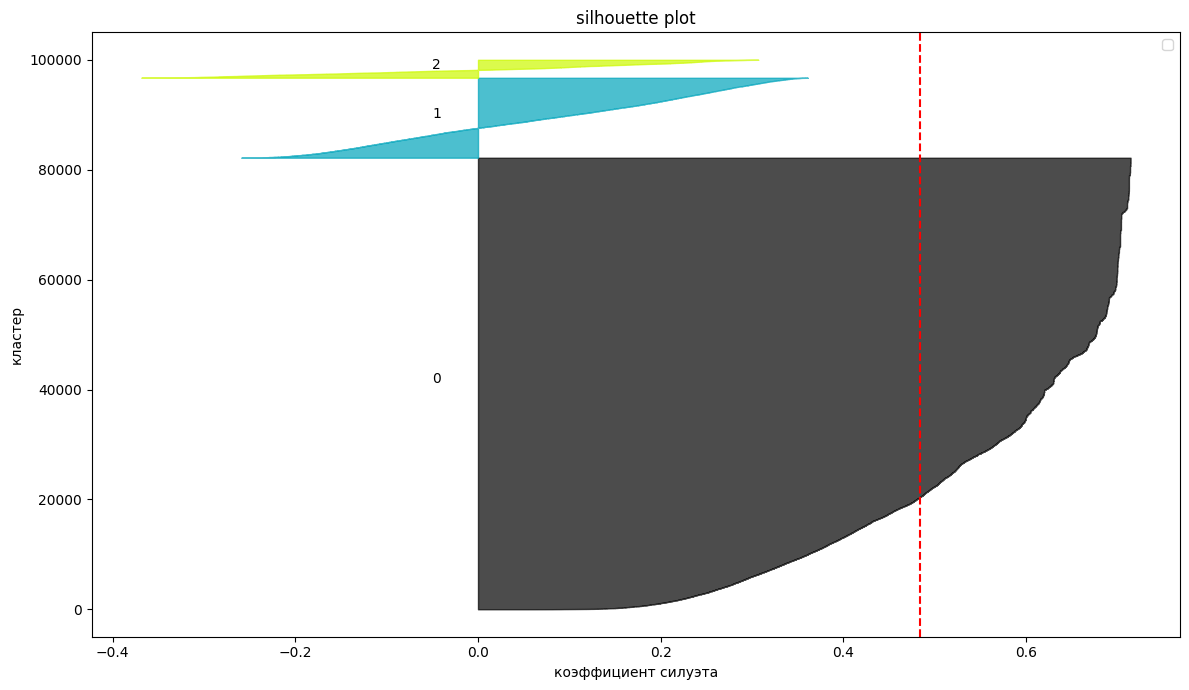

In [34]:
import warnings
warnings.filterwarnings('ignore')

kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels=kmeans.fit_predict(X_sample)

# считаем силуэт для каждой точки
sample_silhouette=silhouette_samples(X_sample, cluster_labels)

fig, ax=plt.subplots(figsize=(12,7))
y_lower=10

for i in range(3):
    ith_cluster_silhouette=sample_silhouette[cluster_labels==i]
    ith_cluster_silhouette.sort()

    y_upper=y_lower+len(ith_cluster_silhouette)
    color=plt.cm.nipy_spectral(float(i)/3)
    ax.fill_betweenx(np.arange(y_lower, y_upper),0, ith_cluster_silhouette, 
                    facecolor=color,edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower+len(ith_cluster_silhouette)/2, str(i))
    y_lower=y_upper+10

ax.axvline(x=silhouette_score(X_sample, cluster_labels), linestyle='--', color='red')
ax.set_xlabel('коэффициент силуэта')
ax.set_ylabel('кластер')
ax.set_title(f'silhouette plot')
ax.legend()
plt.tight_layout()

In [36]:
kmeans_final=KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['cluster_kmeans']=kmeans_final.fit_predict(X_scaled)

print('распределение по кластерам:\n')
df_final['cluster_kmeans'].value_counts().sort_index()

распределение по кластерам:



cluster_kmeans
0    408901
1     17642
2     74103
Name: count, dtype: int64

### Интерпретация кластеров
Средние, стандартные отклонения и медианы признаков для каждого кластера.
По ним определяем поведенческие типы пользователей.

In [32]:
cols = ['total_views', 'total_purchases', 'avg_price_purchased', 'total_spent', 'active_days']

cluster_kmeans_mean=df_final.groupby('cluster_kmeans')[cols].mean().round(2)
cluster_kmeans_std=df_final.groupby('cluster_kmeans')[cols].std().round(2)

cluster_kmeans_mean.columns=[f'{col}_mean' for col in cols]
cluster_kmeans_std.columns=[f'{col}_std' for col in cols]

cluster_stats=pd.concat([cluster_kmeans_mean, cluster_kmeans_std], axis=1)

print(f'статистика по кластерам:\n{cluster_stats}')

cluster_median = df_final.groupby('cluster_kmeans')[cols].median().round(2)

print('-'*100)
print("\nмедианы по кластерам:")
print(cluster_median)

статистика по кластерам:
                total_views_mean  total_purchases_mean  \
cluster_kmeans                                           
0                          11.66                  0.15   
1                          18.25                  2.96   
2                          46.49                  0.25   

                avg_price_purchased_mean  total_spent_mean  active_days_mean  \
cluster_kmeans                                                                 
0                                  16.44             20.82              1.75   
1                                 669.78           1562.83              2.54   
2                                  19.40             30.70              3.63   

                total_views_std  total_purchases_std  avg_price_purchased_std  \
cluster_kmeans                                                                  
0                          8.23                 0.46                    59.78   
1                         22.20         

### Названия кластеров
На основе средних значений:
- Кластер 0: низкая активность, почти нет покупок - «Пассивные зрители»
- Кластер 1: высокий чек, много трат - «VIP покупатели»
- Кластер 2: много просмотров, долго активны - «Активные посетители»

In [33]:
cluster_names = {
    0: "Пассивные зрители",
    1: "VIP покупатели", 
    2: "Активные посетители"
}

df_final['cluster_name'] = df_final['cluster_kmeans'].map(cluster_names)

print("распределение с названиями:\n")
print(df_final['cluster_name'].value_counts())

распределение с названиями:

cluster_name
Пассивные зрители      408901
Активные посетители     74103
VIP покупатели          17642
Name: count, dtype: int64


### Визуализация кластеров в 2D (PCA)
Проецируем 9-мерные данные на 2 главные компоненты.
На графике видно, что основная масса точек (кластер 0) образует плотное облако, а кластеры 1 и 2 находятся на периферии.

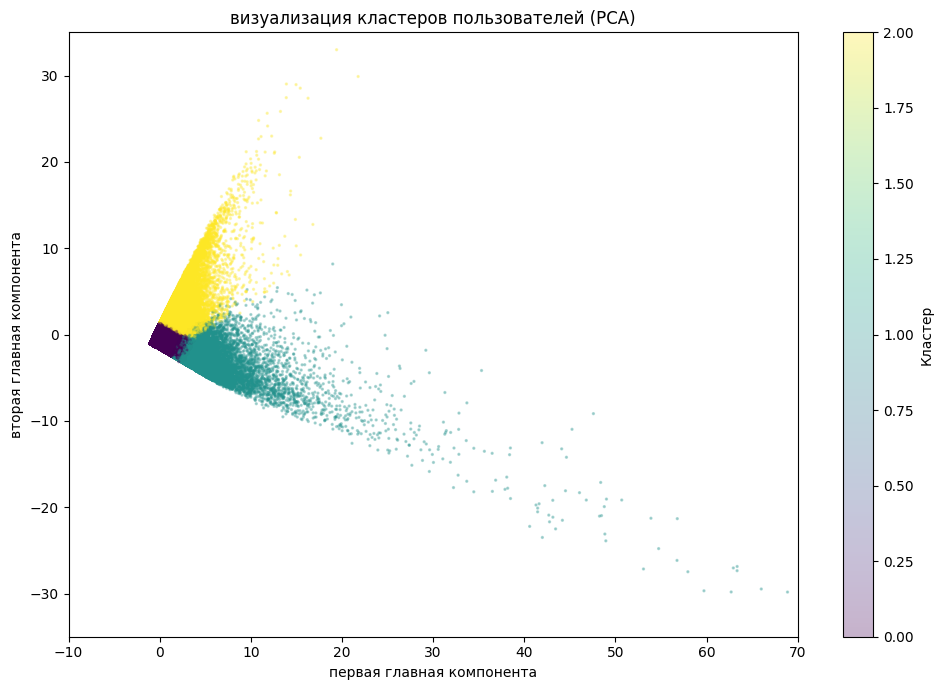

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_final['cluster_kmeans'], 
                       cmap='viridis', alpha=0.3, s=2)
plt.colorbar(scatter, label='Кластер')
plt.xlim(-10,70)
plt.ylim(-35,35)
plt.xlabel('первая главная компонента')
plt.ylabel('вторая главная компонента')
plt.title('визуализация кластеров пользователей (PCA)')
plt.tight_layout()

### Тепловая карта средних значений

Логарифмическая шкала позволяет видеть одновременно маленькие и большие значения.

- **Красный** - высокое значение, **синий** - низкое.
- VIP-кластер (1) выделяется по `total_spent` и `avg_price_purchased`.
- Активный кластер (2) - по `total_views`.

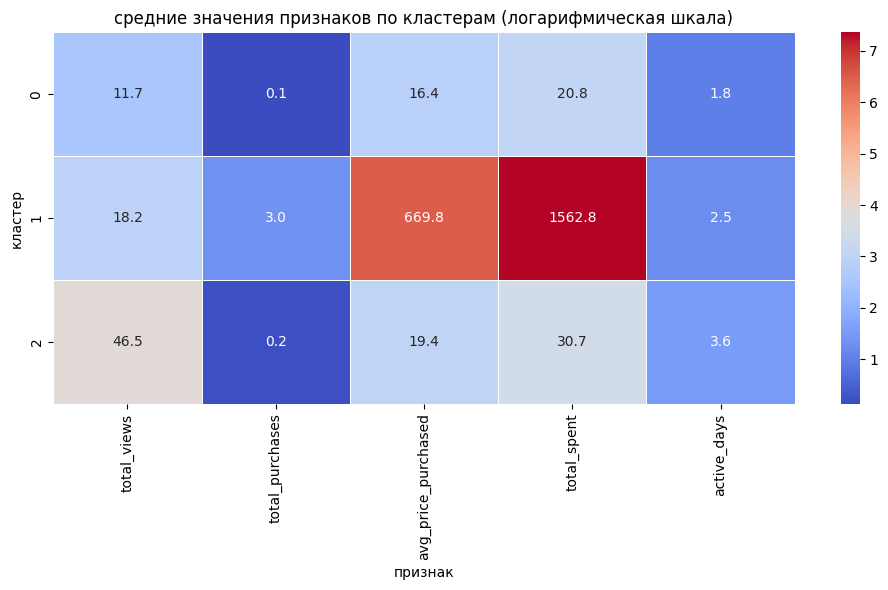

In [51]:
cols = ['total_views', 'total_purchases', 'avg_price_purchased', 'total_spent', 'active_days']
cluster_kmeans_mean = df_final.groupby('cluster_kmeans')[cols].mean().round(2)

# логарифмируем данные для heatmap
log_mean = np.log1p(cluster_kmeans_mean)  # log1p = log(1+x)

plt.figure(figsize=(10, 6))
sns.heatmap(log_mean, annot=cluster_kmeans_mean.values, fmt='.1f', 
            cmap='coolwarm', linewidths=0.5,
            xticklabels=cols, yticklabels=['0', '1', '2'])
plt.title('средние значения признаков по кластерам (логарифмическая шкала)')
plt.ylabel('кластер')
plt.xlabel('признак')
plt.tight_layout()